# E_c Context Feature Diagnostics

이 노트북은 `data/03_features`에 저장된 과거 프레임 조건 feature `E_c`가 window 단위로 충분히 다르게 뽑히는지 검증합니다.

검증 목표는 다음입니다.

1. feature index와 tensor payload의 `sample_id/frame_paths` 정렬이 맞는지 확인
2. 같은 video 인접 window, 같은 video 먼 window, 다른 video/scene 사이의 `E_c` 유사도 비교
3. window 내부 시간 변화량이 충분한지 확인
4. `E_c` 이웃이 비슷한 `E_v` future descriptor를 갖는지 확인
5. 간단한 linear probe로 `E_c -> E_v` 예측 가능성을 확인
6. 모델 ablation에서 쓸 hard context negative 후보를 구성

기존 `Diagnostics.ipynb`가 모델 출력과 anomaly score를 보는 노트북이라면, 이 노트북은 조건 feature 자체의 품질과 정렬을 봅니다.

## 설정

- `FEATURE_SPLIT`은 `train` 또는 `test`입니다.
- `MAX_RECORDS`는 실제 tensor를 로드할 window 수입니다. 너무 크게 잡으면 오래 걸립니다.
- `FUTURE_DESCRIPTOR_GRID`는 `E_v`를 요약할 spatial grid 크기입니다. 기본 4면 `T*C*4*4` descriptor가 됩니다.
- `SAVE_REPORT=True`면 요약 JSON/CSV를 `data/03_features/.../context_diagnostics`에 저장합니다.

In [14]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

try:
    from IPython.display import display
except ImportError:  # pragma: no cover
    display = print

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FEATURE_ROOT = PROJECT_ROOT / "data" / "03_features" / "shanghaitech"
FEATURE_SPLIT = os.environ.get("VAD_CONTEXT_SPLIT", "test")  # train 또는 test
FEATURE_INDEX_PATH = FEATURE_ROOT / f"{FEATURE_SPLIT}_feature_index.jsonl"

MAX_RECORDS = int(os.environ.get("VAD_CONTEXT_MAX_RECORDS", "512"))
MAX_RECORDS_PER_VIDEO = int(os.environ.get("VAD_CONTEXT_MAX_PER_VIDEO", "24"))
FUTURE_DESCRIPTOR_GRID = int(os.environ.get("VAD_CONTEXT_FUTURE_GRID", "4"))
RANDOM_SEED = 42
RIDGE_LAMBDA = 1.0e-2
SAVE_REPORT = True

REPORT_DIR = FEATURE_ROOT / "context_diagnostics"

print(f"project_root={PROJECT_ROOT}")
print(f"feature_index={FEATURE_INDEX_PATH}")
print(f"max_records={MAX_RECORDS}")

project_root=/workspace/VAD
feature_index=/workspace/VAD/data/03_features/shanghaitech/test_feature_index.jsonl
max_records=512


In [15]:
def project_path(path: str | Path | None) -> Path | None:
    if path is None:
        return None
    resolved = Path(path)
    if resolved.is_absolute():
        return resolved
    return PROJECT_ROOT / resolved


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    if not path.is_file():
        raise FileNotFoundError(path)
    records = []
    with path.open("r", encoding="utf-8") as file:
        for line in file:
            if line.strip():
                records.append(json.loads(line))
    return records


def write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, sort_keys=True)
        file.write(chr(10))


def normalize_record_paths(records: list[dict[str, Any]]) -> list[dict[str, Any]]:
    normalized = []
    for record in records:
        item = dict(record)
        for key in (
            "context_feature_path",
            "future_latent_path",
        ):
            if key in item:
                item[key] = str(project_path(item[key]))
        for key in (
            "context_frame_paths",
            "future_frame_paths",
        ):
            if key in item:
                item[key] = [str(project_path(value)) for value in item[key]]
        normalized.append(item)
    return normalized


def balanced_sample(records: list[dict[str, Any]], max_records: int, max_per_video: int) -> list[dict[str, Any]]:
    if len(records) <= max_records:
        return records
    df = pd.DataFrame(records).sort_values(["scene_id", "video_id", "context_start_frame"])
    sampled_parts = []
    for _, group in df.groupby("video_id", sort=False):
        if len(group) <= max_per_video:
            sampled_parts.append(group)
            continue
        positions = np.linspace(0, len(group) - 1, max_per_video).round().astype(int)
        positions = np.unique(positions)
        sampled_parts.append(group.iloc[positions])
    sampled = pd.concat(sampled_parts, ignore_index=True)
    if len(sampled) > max_records:
        sampled = sampled.sample(max_records, random_state=RANDOM_SEED).sort_values(
            ["scene_id", "video_id", "context_start_frame"]
        )
    return sampled.to_dict("records")


def path_signature(paths: list[str]) -> list[str]:
    return [str(Path(path).as_posix()) for path in paths]


def load_torch(path: str | Path) -> dict[str, Any]:
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(path)
    return torch.load(path, map_location="cpu", weights_only=False)


def context_descriptor(embedding: torch.Tensor) -> tuple[torch.Tensor, dict[str, float]]:
    x = embedding.float()
    frame_tokens = x.mean(dim=1)  # [T, D]
    window_vector = F.normalize(x.mean(dim=(0, 1)), dim=0)
    temporal_cos = F.cosine_similarity(frame_tokens[:-1], frame_tokens[1:], dim=1)
    temporal_delta = (frame_tokens[1:] - frame_tokens[:-1]).norm(dim=1)
    token_std = x.std(dim=1, unbiased=False).mean()
    stats = {
        "context_mean": float(x.mean()),
        "context_std": float(x.std(unbiased=False)),
        "context_abs_max": float(x.abs().max()),
        "context_window_norm": float(x.mean(dim=(0, 1)).norm()),
        "temporal_cos_mean": float(temporal_cos.mean()),
        "temporal_cos_min": float(temporal_cos.min()),
        "temporal_delta_mean": float(temporal_delta.mean()),
        "temporal_delta_max": float(temporal_delta.max()),
        "token_std_mean": float(token_std),
    }
    return window_vector.cpu(), stats


def future_descriptor(latent: torch.Tensor, grid: int) -> torch.Tensor:
    z = latent.float()
    if z.ndim != 4:
        raise ValueError(f"future latent must be [T,C,H,W], got {tuple(z.shape)}")
    pooled = F.adaptive_avg_pool2d(z, (grid, grid)).flatten()
    centered = z - z.mean(dim=(-2, -1), keepdim=True)
    spatial_std = centered.square().mean(dim=(-2, -1)).sqrt().flatten()
    descriptor = torch.cat([pooled, spatial_std], dim=0)
    return F.normalize(descriptor, dim=0).cpu()


def cosine_matrix(vectors: torch.Tensor) -> torch.Tensor:
    vectors = F.normalize(vectors.float(), dim=1)
    return vectors @ vectors.T


def summarize_bool(series: pd.Series) -> dict[str, Any]:
    return {
        "count": int(series.shape[0]),
        "true": int(series.sum()),
        "false": int((~series).sum()),
        "true_ratio": float(series.mean()) if len(series) else float("nan"),
    }


def sample_pair_values(values: np.ndarray, sample_size: int = 100_000) -> np.ndarray:
    flat = np.asarray(values).reshape(-1)
    if flat.size <= sample_size:
        return flat
    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(flat.size, size=sample_size, replace=False)
    return flat[idx]


diagnostic_report: dict[str, Any] = {}

## 1. Feature index와 window 정렬 확인

먼저 index metadata가 기대한 window 구조를 갖는지 확인합니다.

필수 조건:

```text
context_end_frame + 1 + gap == future_start_frame
context_frames[0] == context_start_frame
context_frames[-1] == context_end_frame
future_frames[0] == future_start_frame
future_frames[-1] == future_end_frame
```

현재 config에서는 `gap=0`이므로 보통 `future_start_frame = context_end_frame + 1`이어야 합니다.

In [16]:
raw_records = read_jsonl(FEATURE_INDEX_PATH)
records = normalize_record_paths(raw_records)
records = balanced_sample(records, MAX_RECORDS, MAX_RECORDS_PER_VIDEO)
index_df = pd.DataFrame(records)

print(f"raw_records={len(raw_records):,}")
print(f"sampled_records={len(records):,}")
display(
    index_df.groupby(["split", "source_split", "scene_id"], dropna=False)
    .agg(windows=("sample_id", "count"), videos=("video_id", "nunique"), anomaly_ratio=("future_label", "mean"))
    .reset_index()
    .head(50)
)

context_len_ok = index_df.apply(
    lambda row: len(row["context_frames"]) == row["context_end_frame"] - row["context_start_frame"] + 1,
    axis=1,
)
future_len_ok = index_df.apply(
    lambda row: len(row["future_frames"]) == row["future_end_frame"] - row["future_start_frame"] + 1,
    axis=1,
)
context_bounds_ok = index_df.apply(
    lambda row: row["context_frames"][0] == row["context_start_frame"]
    and row["context_frames"][-1] == row["context_end_frame"],
    axis=1,
)
future_bounds_ok = index_df.apply(
    lambda row: row["future_frames"][0] == row["future_start_frame"]
    and row["future_frames"][-1] == row["future_end_frame"],
    axis=1,
)
gap_values = index_df["future_start_frame"] - index_df["context_end_frame"] - 1
path_exists_ok = index_df.apply(
    lambda row: Path(row["context_feature_path"]).is_file() and Path(row["future_latent_path"]).is_file(),
    axis=1,
)

alignment_summary = pd.DataFrame(
    [
        {"check": "context_len_ok", **summarize_bool(context_len_ok)},
        {"check": "future_len_ok", **summarize_bool(future_len_ok)},
        {"check": "context_bounds_ok", **summarize_bool(context_bounds_ok)},
        {"check": "future_bounds_ok", **summarize_bool(future_bounds_ok)},
        {"check": "feature_paths_exist", **summarize_bool(path_exists_ok)},
    ]
)

display(alignment_summary)
display(gap_values.describe().to_frame("gap_frames"))

diagnostic_report["index"] = {
    "feature_index": str(FEATURE_INDEX_PATH),
    "raw_records": len(raw_records),
    "sampled_records": len(records),
    "gap_min": int(gap_values.min()),
    "gap_max": int(gap_values.max()),
    "alignment_summary": alignment_summary.to_dict("records"),
}

raw_records=9,208
sampled_records=512


,split,source_split,scene_id,windows,videos,anomaly_ratio
0,test,test,scene_01,174,33,0.494253
1,test,test,scene_02,13,3,0.461538
2,test,test,scene_03,53,10,0.415094
3,test,test,scene_04,37,9,0.486486
4,test,test,scene_05,41,7,0.317073
5,test,test,scene_06,34,6,0.470588
6,test,test,scene_07,37,8,0.351351
7,test,test,scene_08,52,12,0.557692
8,test,test,scene_09,2,1,0.000000
9,test,test,scene_10,22,5,0.727273


,check,count,true,false,true_ratio
0,context_len_ok,512,512,0,1.0
1,future_len_ok,512,512,0,1.0
2,context_bounds_ok,512,512,0,1.0
3,future_bounds_ok,512,512,0,1.0
4,feature_paths_exist,512,512,0,1.0


,gap_frames
count,512.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


## 2. Tensor payload 정합성 및 descriptor 로드

각 window의 cached tensor를 읽어서 다음을 확인합니다.

- feature index의 `sample_id`와 tensor payload의 `sample_id`가 같은가
- index의 frame paths와 payload의 frame paths가 같은가
- `E_c` shape, `E_v` shape가 일관적인가
- window-level pooled `E_c` descriptor와 요약된 `E_v` descriptor를 만든다

In [18]:
context_vectors = []
future_vectors = []
window_stat_rows = []
payload_check_rows = []

for record in tqdm(records, desc="load E_c/E_v tensors", unit="window"):
    context_payload = load_torch(record["context_feature_path"])
    future_payload = load_torch(record["future_latent_path"])
    context = context_payload["embedding"]
    future = future_payload["latent"]

    context_vector, context_stats = context_descriptor(context)
    future_vector = future_descriptor(future, grid=FUTURE_DESCRIPTOR_GRID)
    context_vectors.append(context_vector)
    future_vectors.append(future_vector)

    payload_sample_ok = (
        context_payload.get("sample_id") == record["sample_id"]
        and future_payload.get("sample_id") == record["sample_id"]
    )
    payload_context_paths = [str(project_path(path)) for path in context_payload.get("frame_paths", [])]
    payload_future_paths = [str(project_path(path)) for path in future_payload.get("frame_paths", [])]
    context_paths_ok = path_signature(payload_context_paths) == path_signature(record["context_frame_paths"])
    future_paths_ok = path_signature(payload_future_paths) == path_signature(record["future_frame_paths"])

    payload_check_rows.append(
        {
            "sample_id": record["sample_id"],
            "video_id": record["video_id"],
            "scene_id": record.get("scene_id"),
            "payload_sample_ok": payload_sample_ok,
            "context_paths_ok": context_paths_ok,
            "future_paths_ok": future_paths_ok,
            "context_shape": tuple(context.shape),
            "future_shape": tuple(future.shape),
        }
    )
    window_stat_rows.append(
        {
            "sample_id": record["sample_id"],
            "video_id": record["video_id"],
            "scene_id": record.get("scene_id"),
            "context_start_frame": int(record["context_start_frame"]),
            "context_end_frame": int(record["context_end_frame"]),
            "future_start_frame": int(record["future_start_frame"]),
            "future_label": int(record.get("future_label", 0)),
            **context_stats,
        }
    )

context_vectors = torch.stack(context_vectors)
future_vectors = torch.stack(future_vectors)
payload_checks = pd.DataFrame(payload_check_rows)
window_stats = pd.DataFrame(window_stat_rows)

payload_summary = pd.DataFrame(
    [
        {"check": "payload_sample_ok", **summarize_bool(payload_checks["payload_sample_ok"])},
        {"check": "context_paths_ok", **summarize_bool(payload_checks["context_paths_ok"])},
        {"check": "future_paths_ok", **summarize_bool(payload_checks["future_paths_ok"])},
    ]
)

display(payload_summary)
display(payload_checks[["context_shape", "future_shape"]].value_counts().reset_index(name="count"))
display(window_stats.describe(include="all").T.head(30))

print(f"context_vectors={tuple(context_vectors.shape)}")
print(f"future_vectors={tuple(future_vectors.shape)}")

diagnostic_report["payload_summary"] = payload_summary.to_dict("records")
diagnostic_report["context_vector_shape"] = list(context_vectors.shape)
diagnostic_report["future_vector_shape"] = list(future_vectors.shape)

load E_c/E_v tensors: 100%|██████████| 512/512 [04:46<00:00,  1.78window/s]


,check,count,true,false,true_ratio
0,payload_sample_ok,512,512,0,1.0
1,context_paths_ok,512,512,0,1.0
2,future_paths_ok,512,512,0,1.0


,context_shape,future_shape,count
0,"(32, 256, 768)","(8, 4, 32, 32)",512


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sample_id,512,512,01_0015_000017_000049,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
video_id,512,105,01_0076,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scene_id,512,12,scene_01,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
context_start_frame,512.0,NaN,NaN,NaN,182.046875,146.170951,1.0,73.0,153.0,265.0,857.0
context_end_frame,512.0,NaN,NaN,NaN,213.046875,146.170951,32.0,104.0,184.0,296.0,888.0
future_start_frame,512.0,NaN,NaN,NaN,214.046875,146.170951,33.0,105.0,185.0,297.0,889.0
future_label,512.0,NaN,NaN,NaN,0.498047,0.500485,0.0,0.0,0.0,1.0,1.0
context_mean,512.0,NaN,NaN,NaN,0.00842,0.005456,-0.002515,0.004026,0.008674,0.012951,0.019065
context_std,512.0,NaN,NaN,NaN,1.94973,0.103502,1.697299,1.859492,1.943569,2.025985,2.187453
context_abs_max,512.0,NaN,NaN,NaN,487.647461,31.037904,415.5,475.1875,495.875,510.25,549.5


context_vectors=(512, 768)
future_vectors=(512, 544)


## 3. Window 내부 시간 변화량 확인

`temporal_cos_mean`이 1에 너무 가깝고 `temporal_delta_mean`이 작으면, DINO patch feature가 window 안에서 거의 변하지 않는다는 뜻입니다. 이 경우 미래 예측 조건으로 사용할 때 sample-specific signal이 약할 수 있습니다.

,count,mean,std,min,25%,50%,75%,max
temporal_cos_mean,512.0,0.998990,0.000540,0.995431,0.998750,0.999069,0.999351,0.999810
temporal_cos_min,512.0,0.997437,0.001625,0.987779,0.996852,0.997824,0.998511,0.999661
temporal_delta_mean,512.0,0.654172,0.176661,0.266872,0.531510,0.645441,0.769663,1.445341
temporal_delta_max,512.0,1.153565,0.389012,0.377200,0.867793,1.106585,1.373595,2.940320
token_std_mean,512.0,0.944101,0.024981,0.870177,0.926947,0.945001,0.962473,1.001792
context_window_norm,512.0,14.513027,0.784900,12.315440,14.007272,14.519829,15.079490,16.362997
future_label,512.0,0.498047,0.500485,0.000000,0.000000,0.000000,1.000000,1.000000


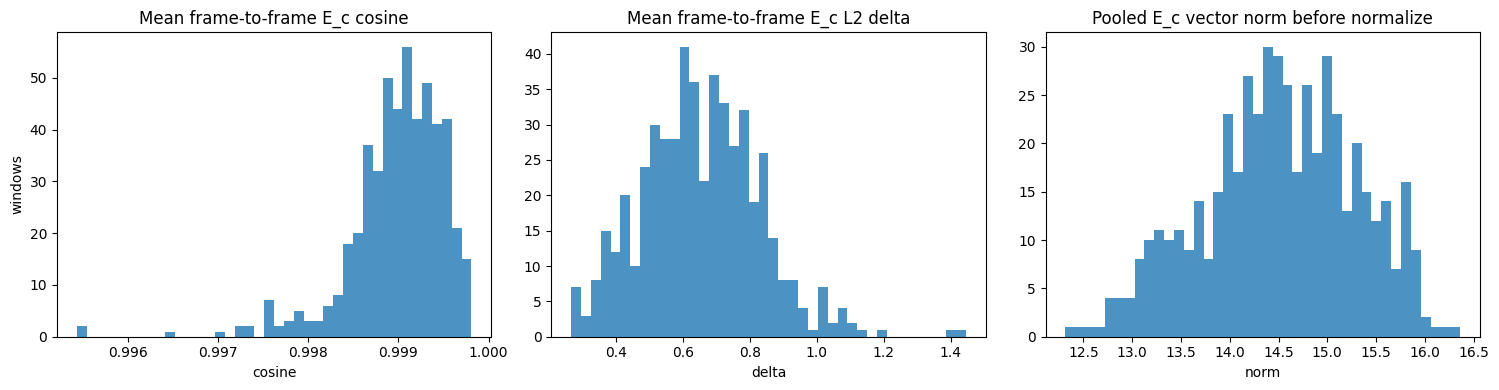

,temporal_cos_mean,temporal_cos_min,temporal_delta_mean,temporal_delta_max,token_std_mean,context_window_norm
future_label,,,,,,
0,0.999067,0.997429,0.628585,1.165078,0.946039,14.554251
1,0.998912,0.997446,0.679960,1.141961,0.942148,14.471480


In [19]:
temporal_columns = [
    "temporal_cos_mean",
    "temporal_cos_min",
    "temporal_delta_mean",
    "temporal_delta_max",
    "token_std_mean",
    "context_window_norm",
]

display(window_stats[temporal_columns + ["future_label"]].describe().T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(window_stats["temporal_cos_mean"], bins=40, alpha=0.8)
axes[0].set_title("Mean frame-to-frame E_c cosine")
axes[0].set_xlabel("cosine")
axes[0].set_ylabel("windows")

axes[1].hist(window_stats["temporal_delta_mean"], bins=40, alpha=0.8)
axes[1].set_title("Mean frame-to-frame E_c L2 delta")
axes[1].set_xlabel("delta")

axes[2].hist(window_stats["context_window_norm"], bins=40, alpha=0.8)
axes[2].set_title("Pooled E_c vector norm before normalize")
axes[2].set_xlabel("norm")
plt.tight_layout()
plt.show()

if "future_label" in window_stats.columns and window_stats["future_label"].nunique() > 1:
    display(window_stats.groupby("future_label")[temporal_columns].mean())

## 4. 동일 영상 정상→이상 context 변화 분석

질문은 같은 video 안에서 정상 구간 context와 이상 프레임이 섞인 context가 실제로 다른 `E_c`로 뽑히는지입니다.

feature index에는 `context_frame_labels`가 없으므로, 전체 feature index의 `future_frame_labels`를 video별 frame label map으로 재구성한 뒤 sampled window의 `context_frames`에 label을 다시 매핑합니다.

window를 다음처럼 나눕니다.

```text
normal_context: context frames 중 anomaly label이 없음
transition_context: context frames 안에 정상/이상 label이 섞임
anomaly_context: known context frames가 모두 anomaly label
unknown: context frame label을 충분히 복원하지 못함
```

그리고 같은 video의 정상 context centroid와 각 window의 `E_c` cosine을 봅니다.

In [20]:
def build_video_frame_label_map(source_records: list[dict[str, Any]]) -> dict[str, dict[int, int]]:
    label_map: dict[str, dict[int, int]] = {}
    for record in source_records:
        bucket = label_map.setdefault(str(record["video_id"]), {})
        for frame, label in zip(
            record.get("future_frames", []),
            record.get("future_frame_labels", []),
            strict=True,
        ):
            frame_idx = int(frame)
            bucket[frame_idx] = max(int(label), bucket.get(frame_idx, 0))
    return label_map


def context_state_from_labels(labels: list[int | None]) -> tuple[str, int, float, float]:
    known = [int(label) for label in labels if label is not None]
    if not known:
        return "unknown", 0, float("nan"), 0.0
    anomaly_count = int(sum(known))
    anomaly_ratio = anomaly_count / len(known)
    known_ratio = len(known) / len(labels) if labels else 0.0
    if anomaly_count == 0:
        return "normal_context", anomaly_count, anomaly_ratio, known_ratio
    if anomaly_count == len(known):
        return "anomaly_context", anomaly_count, anomaly_ratio, known_ratio
    return "transition_context", anomaly_count, anomaly_ratio, known_ratio


def video_onset_frames(label_map: dict[str, dict[int, int]]) -> dict[str, int | None]:
    onset = {}
    for video_id, labels in label_map.items():
        anomaly_frames = [frame for frame, label in labels.items() if int(label) == 1]
        onset[video_id] = min(anomaly_frames) if anomaly_frames else None
    return onset


video_label_map = build_video_frame_label_map(raw_records)
onset_by_video = video_onset_frames(video_label_map)
context_label_rows = []
for row_idx, record in enumerate(records):
    labels_for_video = video_label_map.get(record["video_id"], {})
    context_labels = [labels_for_video.get(int(frame)) for frame in record["context_frames"]]
    state, anomaly_count, anomaly_ratio, known_ratio = context_state_from_labels(context_labels)
    future_labels = [int(label) for label in record.get("future_frame_labels", [])]
    onset = onset_by_video.get(record["video_id"])
    context_label_rows.append(
        {
            "row_idx": row_idx,
            "sample_id": record["sample_id"],
            "video_id": record["video_id"],
            "scene_id": record.get("scene_id"),
            "context_start_frame": int(record["context_start_frame"]),
            "context_end_frame": int(record["context_end_frame"]),
            "future_start_frame": int(record["future_start_frame"]),
            "future_end_frame": int(record["future_end_frame"]),
            "video_anomaly_onset_frame": onset,
            "distance_context_end_to_onset": (
                int(record["context_end_frame"]) - int(onset) if onset is not None else np.nan
            ),
            "distance_future_start_to_onset": (
                int(record["future_start_frame"]) - int(onset) if onset is not None else np.nan
            ),
            "context_state": state,
            "context_label_known_ratio": known_ratio,
            "context_anomaly_frames": anomaly_count,
            "context_anomaly_ratio": anomaly_ratio,
            "future_anomaly_frames": int(sum(future_labels)) if future_labels else 0,
            "future_anomaly_ratio": float(np.mean(future_labels)) if future_labels else np.nan,
        }
    )

context_label_df = pd.DataFrame(context_label_rows)

# Add context label columns to window_stats so later pair/hard-negative analysis can reuse them.
window_stats = window_stats.merge(
    context_label_df[
        [
            "sample_id",
            "context_state",
            "context_label_known_ratio",
            "context_anomaly_frames",
            "context_anomaly_ratio",
            "future_anomaly_ratio",
            "video_anomaly_onset_frame",
            "distance_context_end_to_onset",
            "distance_future_start_to_onset",
        ]
    ],
    on="sample_id",
    how="left",
)

normal_centroids: dict[str, torch.Tensor] = {}
for video_id, group in context_label_df.groupby("video_id"):
    normal_rows = group[group["context_state"] == "normal_context"]["row_idx"].astype(int).tolist()
    if len(normal_rows) == 0:
        continue
    centroid = context_vectors[normal_rows].float().mean(dim=0)
    normal_centroids[str(video_id)] = F.normalize(centroid, dim=0)

cos_to_normal = []
for _, row in context_label_df.iterrows():
    centroid = normal_centroids.get(str(row["video_id"]))
    if centroid is None:
        cos_to_normal.append(np.nan)
        continue
    vector = F.normalize(context_vectors[int(row["row_idx"])].float(), dim=0)
    cos_to_normal.append(float(torch.dot(vector, centroid)))
context_label_df["cos_to_video_normal_context_centroid"] = cos_to_normal
context_label_df["distance_to_video_normal_context_centroid"] = (
    1.0 - context_label_df["cos_to_video_normal_context_centroid"]
)
window_stats = window_stats.merge(
    context_label_df[
        [
            "sample_id",
            "cos_to_video_normal_context_centroid",
            "distance_to_video_normal_context_centroid",
        ]
    ],
    on="sample_id",
    how="left",
)

context_state_summary = (
    context_label_df.groupby("context_state", dropna=False)
    .agg(
        windows=("sample_id", "count"),
        videos=("video_id", "nunique"),
        context_anomaly_ratio_mean=("context_anomaly_ratio", "mean"),
        future_anomaly_ratio_mean=("future_anomaly_ratio", "mean"),
        cos_to_normal_centroid_mean=("cos_to_video_normal_context_centroid", "mean"),
        cos_to_normal_centroid_p10=(
            "cos_to_video_normal_context_centroid",
            lambda x: x.quantile(0.10),
        ),
        cos_to_normal_centroid_p50=("cos_to_video_normal_context_centroid", "median"),
        cos_to_normal_centroid_p90=(
            "cos_to_video_normal_context_centroid",
            lambda x: x.quantile(0.90),
        ),
        distance_context_end_to_onset_mean=("distance_context_end_to_onset", "mean"),
    )
    .reset_index()
)

display(context_state_summary)
display(
    context_label_df.sort_values(
        ["video_id", "context_start_frame"]
    )[
        [
            "sample_id",
            "video_id",
            "context_start_frame",
            "context_end_frame",
            "video_anomaly_onset_frame",
            "context_state",
            "context_anomaly_ratio",
            "future_anomaly_ratio",
            "cos_to_video_normal_context_centroid",
        ]
    ].head(30)
)

diagnostic_report["context_transition_summary"] = context_state_summary.to_dict("records")
diagnostic_report["context_transition_counts"] = (
    context_label_df["context_state"].value_counts(dropna=False).to_dict()
)


,context_state,windows,videos,context_anomaly_ratio_mean,future_anomaly_ratio_mean,cos_to_normal_centroid_mean,cos_to_normal_centroid_p10,cos_to_normal_centroid_p50,cos_to_normal_centroid_p90,distance_context_end_to_onset_mean
0,anomaly_context,166,78,1.000000,0.920181,0.988995,0.978500,0.992560,0.997729,127.765060
1,normal_context,195,81,0.000000,0.037179,0.997732,0.994583,0.998912,1.000000,63.384615
2,transition_context,128,73,0.584698,0.571289,0.992549,0.983559,0.996369,0.999157,102.710938
3,unknown,23,23,NaN,0.119565,0.994414,0.988313,0.995908,0.999047,-91.565217


,sample_id,video_id,context_start_frame,context_end_frame,video_anomaly_onset_frame,context_state,context_anomaly_ratio,future_anomaly_ratio,cos_to_video_normal_context_centroid
0,01_0015_000017_000049,01_0015,17,48,87,normal_context,0.00000,0.000,1.000000
1,01_0015_000085_000117,01_0015,85,116,87,transition_context,0.93750,1.000,0.995598
2,01_0015_000105_000137,01_0015,105,136,87,anomaly_context,1.00000,1.000,0.994293
3,01_0015_000325_000357,01_0015,325,356,87,anomaly_context,1.00000,1.000,0.997497
4,01_0015_000341_000373,01_0015,341,372,87,anomaly_context,1.00000,0.250,0.998568
5,01_0016_000001_000033,01_0016,1,32,189,unknown,NaN,0.000,0.995899
6,01_0016_000013_000045,01_0016,13,44,189,normal_context,0.00000,0.000,0.997154
7,01_0016_000041_000073,01_0016,41,72,189,normal_context,0.00000,0.000,0.998013
8,01_0016_000105_000137,01_0016,105,136,189,normal_context,0.00000,0.000,0.998758
9,01_0016_000117_000149,01_0016,117,148,189,normal_context,0.00000,0.000,0.998912


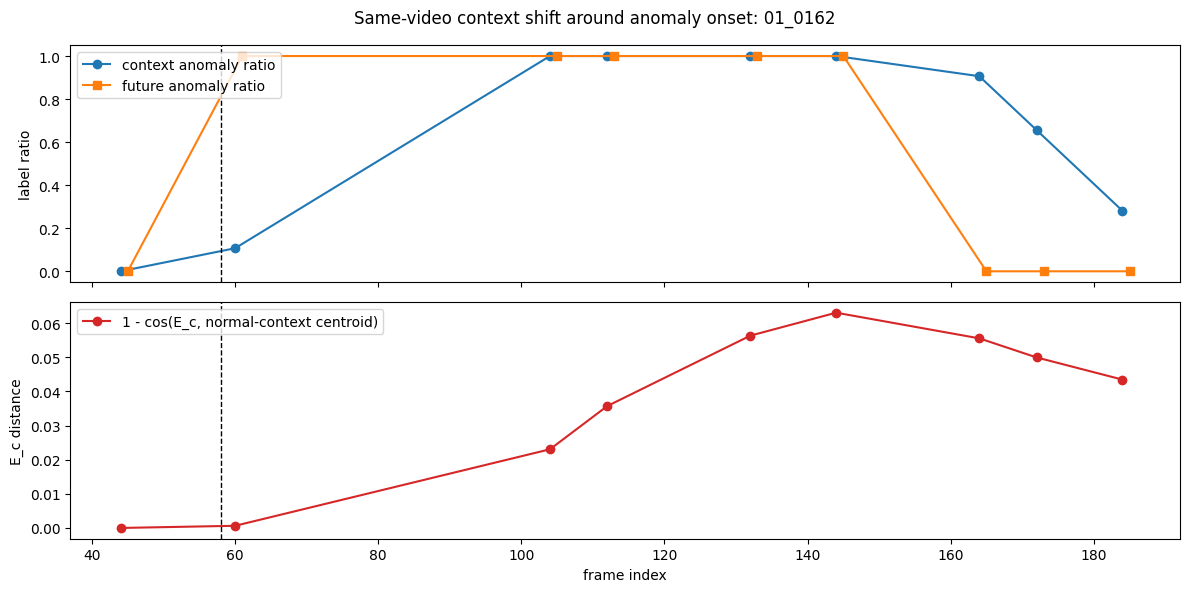

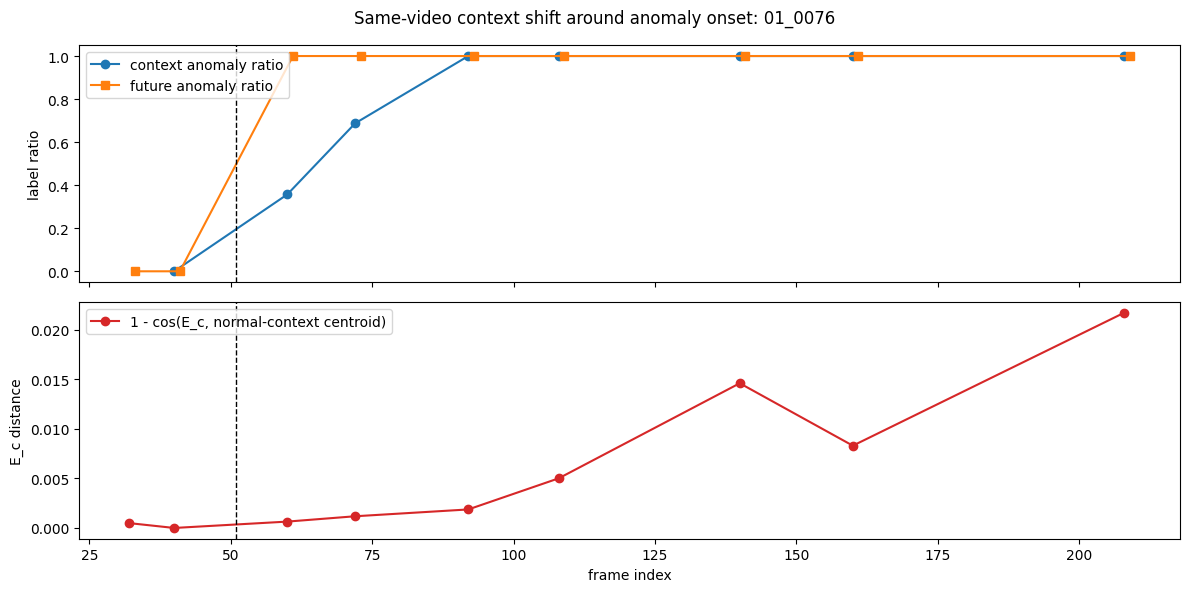

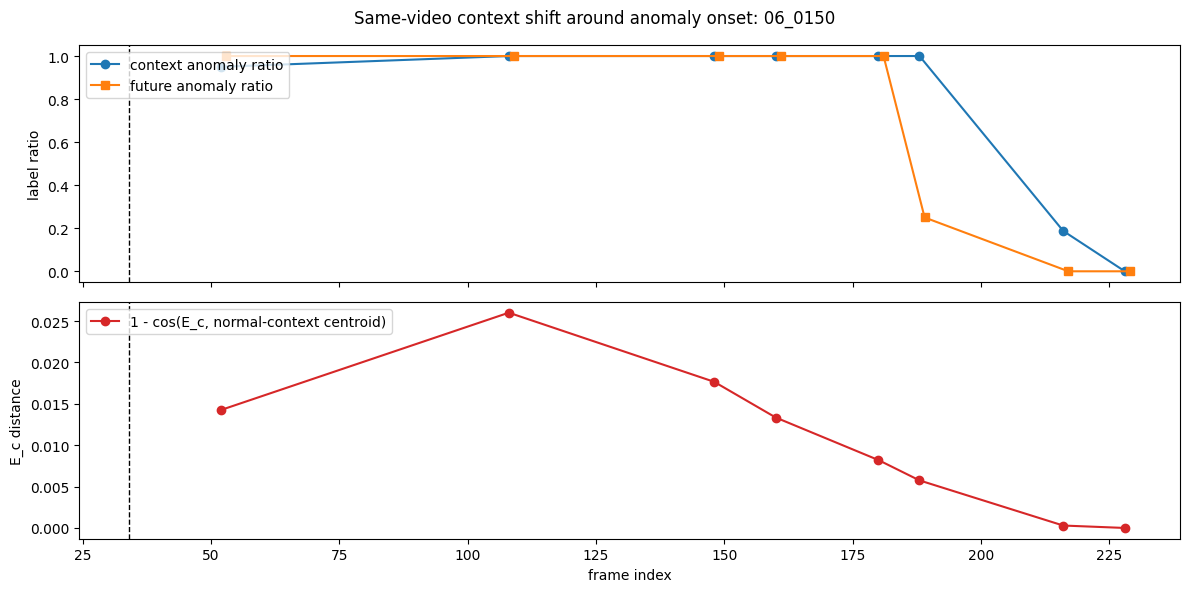

In [21]:
videos_with_transition = (
    context_label_df[context_label_df["context_state"].isin(["transition_context", "anomaly_context"])]
    .groupby("video_id")
    .size()
    .sort_values(ascending=False)
)
selected_videos = videos_with_transition.head(3).index.tolist()

if not selected_videos:
    print("No sampled windows with transition/anomaly context. Increase MAX_RECORDS or MAX_RECORDS_PER_VIDEO.")
else:
    for video_id in selected_videos:
        timeline = context_label_df[context_label_df["video_id"] == video_id].sort_values(
            "context_start_frame"
        )
        onset = onset_by_video.get(video_id)
        fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        axes[0].plot(
            timeline["context_end_frame"],
            timeline["context_anomaly_ratio"],
            marker="o",
            label="context anomaly ratio",
        )
        axes[0].plot(
            timeline["future_start_frame"],
            timeline["future_anomaly_ratio"],
            marker="s",
            label="future anomaly ratio",
        )
        axes[0].set_ylabel("label ratio")
        axes[0].set_ylim(-0.05, 1.05)
        axes[0].legend(loc="upper left")

        axes[1].plot(
            timeline["context_end_frame"],
            timeline["distance_to_video_normal_context_centroid"],
            marker="o",
            color="tab:red",
            label="1 - cos(E_c, normal-context centroid)",
        )
        axes[1].set_ylabel("E_c distance")
        axes[1].set_xlabel("frame index")
        axes[1].legend(loc="upper left")
        if onset is not None:
            for ax in axes:
                ax.axvline(onset, color="black", linestyle="--", linewidth=1, label="onset")
        fig.suptitle(f"Same-video context shift around anomaly onset: {video_id}")
        plt.tight_layout()
        plt.show()


## 5. E_c window 간 cosine similarity

비교해야 하는 관계는 다음입니다.

- `same_video_adjacent`: 같은 video의 인접 sampled window
- `same_video_far`: 같은 video지만 frame 거리가 큰 window
- `same_scene_diff_video`: 같은 scene이지만 다른 video
- `different_scene`: scene도 다른 window

좋은 조건 feature라면 보통 다음 패턴이 보입니다.

```text
same_video_adjacent > same_video_far > same_scene_diff_video > different_scene
```

모든 category가 비슷하게 0.95 이상이면 `E_c`가 window 구분을 거의 못 할 수 있습니다.

In [22]:
context_cos = cosine_matrix(context_vectors).cpu().numpy()
future_cos = cosine_matrix(future_vectors).cpu().numpy()
meta = window_stats.reset_index(names="row_idx")


def build_pair_table(meta: pd.DataFrame, max_pairs_per_category: int = 10_000) -> pd.DataFrame:
    rng = np.random.default_rng(RANDOM_SEED)
    rows = []

    # same video adjacent and far pairs.
    for _, group in meta.sort_values(["video_id", "context_start_frame"]).groupby("video_id"):
        indices = group["row_idx"].to_numpy()
        starts = group["context_start_frame"].to_numpy()
        if len(indices) >= 2:
            for left, right in zip(indices[:-1], indices[1:], strict=False):
                rows.append({"i": int(left), "j": int(right), "category": "same_video_adjacent"})
            for pos, left in enumerate(indices):
                distances = np.abs(starts - starts[pos])
                far_candidates = indices[distances == distances.max()]
                if len(far_candidates):
                    rows.append({"i": int(left), "j": int(far_candidates[0]), "category": "same_video_far"})

    # same scene different video.
    for _, group in meta.groupby("scene_id", dropna=False):
        video_ids = group["video_id"].unique()
        if len(video_ids) < 2:
            continue
        group_indices = group["row_idx"].to_numpy()
        for left in group_indices:
            left_video = meta.loc[left, "video_id"]
            candidates = group[group["video_id"] != left_video]["row_idx"].to_numpy()
            if len(candidates):
                rows.append({"i": int(left), "j": int(rng.choice(candidates)), "category": "same_scene_diff_video"})

    # different scene.
    all_indices = meta["row_idx"].to_numpy()
    for left in all_indices:
        left_scene = meta.loc[left, "scene_id"]
        candidates = meta[meta["scene_id"] != left_scene]["row_idx"].to_numpy()
        if len(candidates):
            rows.append({"i": int(left), "j": int(rng.choice(candidates)), "category": "different_scene"})

    pair_df = pd.DataFrame(rows).drop_duplicates(["i", "j", "category"])
    sampled_parts = []
    for category, group in pair_df.groupby("category"):
        if len(group) > max_pairs_per_category:
            group = group.sample(max_pairs_per_category, random_state=RANDOM_SEED)
        sampled_parts.append(group)
    return pd.concat(sampled_parts, ignore_index=True) if sampled_parts else pd.DataFrame()


pair_df = build_pair_table(meta)
pair_df["context_cos"] = [float(context_cos[i, j]) for i, j in zip(pair_df["i"], pair_df["j"], strict=True)]
pair_df["future_cos"] = [float(future_cos[i, j]) for i, j in zip(pair_df["i"], pair_df["j"], strict=True)]
pair_df["start_distance"] = [
    int(abs(meta.loc[i, "context_start_frame"] - meta.loc[j, "context_start_frame"]))
    for i, j in zip(pair_df["i"], pair_df["j"], strict=True)
]
pair_df["same_future_label"] = [
    int(meta.loc[i, "future_label"] == meta.loc[j, "future_label"])
    for i, j in zip(pair_df["i"], pair_df["j"], strict=True)
]

pair_summary = (
    pair_df.groupby("category")
    .agg(
        pairs=("context_cos", "count"),
        context_cos_mean=("context_cos", "mean"),
        context_cos_std=("context_cos", "std"),
        context_cos_p10=("context_cos", lambda x: x.quantile(0.10)),
        context_cos_p50=("context_cos", "median"),
        context_cos_p90=("context_cos", lambda x: x.quantile(0.90)),
        future_cos_mean=("future_cos", "mean"),
        start_distance_mean=("start_distance", "mean"),
        same_future_label_ratio=("same_future_label", "mean"),
    )
    .reset_index()
    .sort_values("context_cos_mean", ascending=False)
)

display(pair_summary)
display(pair_df.head(20))

diagnostic_report["pair_summary"] = pair_summary.to_dict("records")

,category,pairs,context_cos_mean,context_cos_std,context_cos_p10,context_cos_p50,context_cos_p90,future_cos_mean,start_distance_mean,same_future_label_ratio
2,same_video_adjacent,407,0.994727,0.007736,0.986750,0.997383,0.999500,0.988956,62.004914,0.690418
3,same_video_far,510,0.989096,0.010354,0.977494,0.991918,0.997518,0.986706,221.772549,0.513725
1,same_scene_diff_video,507,0.980873,0.013522,0.962574,0.984421,0.994584,0.933388,147.605523,0.491124
0,different_scene,512,0.872446,0.050016,0.808729,0.865539,0.944925,0.551655,175.750000,0.488281


,i,j,category,context_cos,future_cos,start_distance,same_future_label
0,0,257,different_scene,0.888048,0.780506,700,1
1,1,264,different_scene,0.910954,0.795755,44,1
2,2,253,different_scene,0.905881,0.778485,468,0
3,3,510,different_scene,0.945163,0.857782,256,1
4,4,426,different_scene,0.874709,0.599446,300,0
5,5,458,different_scene,0.943890,0.836312,488,0
6,6,450,different_scene,0.952676,0.865880,160,0
7,7,498,different_scene,0.940431,0.853410,244,0
8,8,209,different_scene,0.831228,0.376796,88,0
9,9,471,different_scene,0.940317,0.829777,56,0


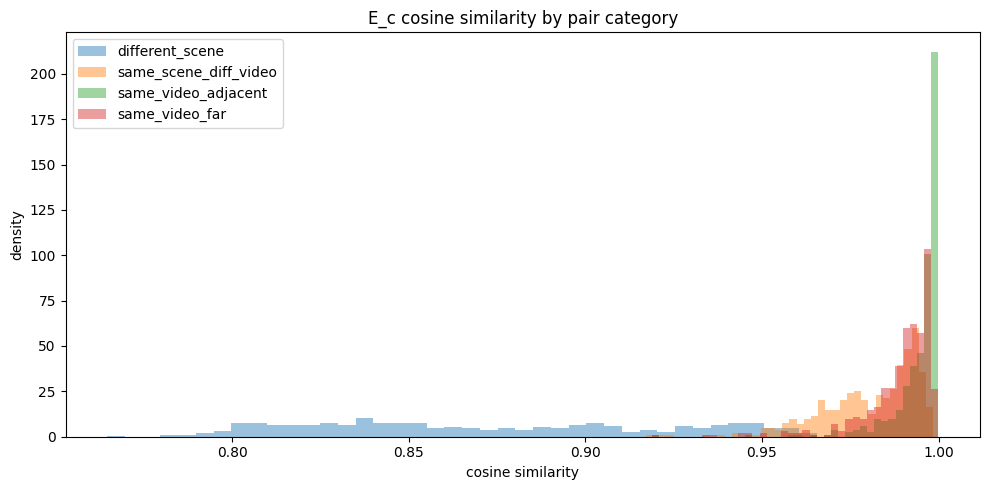

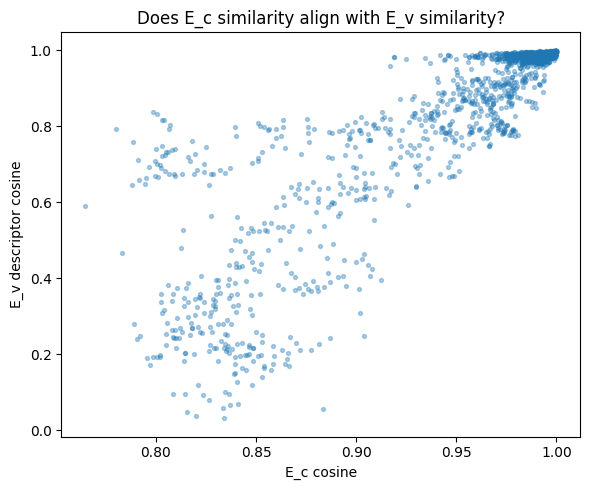

,context_cos,future_cos,start_distance
context_cos,1.000000,0.886094,-0.063542
future_cos,0.886094,1.000000,-0.064333
start_distance,-0.063542,-0.064333,1.000000


In [23]:
plt.figure(figsize=(10, 5))
for category, group in pair_df.groupby("category"):
    plt.hist(group["context_cos"], bins=40, alpha=0.45, density=True, label=category)
plt.title("E_c cosine similarity by pair category")
plt.xlabel("cosine similarity")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(pair_df["context_cos"], pair_df["future_cos"], s=8, alpha=0.35)
plt.title("Does E_c similarity align with E_v similarity?")
plt.xlabel("E_c cosine")
plt.ylabel("E_v descriptor cosine")
plt.tight_layout()
plt.show()

corr = pair_df[["context_cos", "future_cos", "start_distance"]].corr(numeric_only=True)
display(corr)

## 6. E_c nearest neighbor가 비슷한 E_v를 갖는가

`E_c` 기준 top-k 이웃을 찾고, 그 이웃의 `E_v` descriptor가 random 이웃보다 더 비슷한지 봅니다.

이 결과가 random과 거의 같으면 `E_c` 유사도가 미래 latent의 유사도와 잘 연결되지 않는다는 뜻입니다.

In [24]:
def nearest_neighbor_future_table(k_values: list[int]) -> pd.DataFrame:
    rng = np.random.default_rng(RANDOM_SEED)
    n = context_cos.shape[0]
    masked_context = context_cos.copy()
    np.fill_diagonal(masked_context, -np.inf)
    random_future = []
    rows = []
    for i in range(n):
        random_candidates = [j for j in range(n) if j != i]
        if random_candidates:
            random_future.append(future_cos[i, int(rng.choice(random_candidates))])
    random_mean = float(np.mean(random_future)) if random_future else float("nan")

    for k in k_values:
        topk = np.argpartition(-masked_context, kth=min(k, n - 1) - 1, axis=1)[:, :k]
        topk_future = np.array([[future_cos[i, j] for j in topk[i]] for i in range(n)])
        topk_context = np.array([[context_cos[i, j] for j in topk[i]] for i in range(n)])
        rows.append(
            {
                "k": k,
                "topk_context_cos_mean": float(topk_context.mean()),
                "topk_future_cos_mean": float(topk_future.mean()),
                "random_future_cos_mean": random_mean,
                "future_lift_over_random": float(topk_future.mean() - random_mean),
            }
        )
    return pd.DataFrame(rows)

nn_summary = nearest_neighbor_future_table([1, 3, 5, 10])
display(nn_summary)
diagnostic_report["nearest_neighbor_future_summary"] = nn_summary.to_dict("records")

,k,topk_context_cos_mean,topk_future_cos_mean,random_future_cos_mean,future_lift_over_random
0,1,0.997693,0.989805,0.603902,0.385902
1,3,0.996117,0.985976,0.603902,0.382073
2,5,0.995204,0.983840,0.603902,0.379938
3,10,0.993612,0.979979,0.603902,0.376077


## 7. Linear probe: pooled E_c -> summarized E_v

`E_c`가 미래 latent를 조건으로 설명할 수 있는지 아주 단순한 ridge regression으로 봅니다.

이 probe가 높은 성능을 내야 DiT가 반드시 잘 된다는 뜻은 아닙니다. 반대로 이 probe가 mean baseline과 거의 같거나 더 나쁘면, 현재 pooled `E_c`에는 `E_v`를 예측할 신호가 약할 수 있습니다.

In [25]:
def standardize_train_val(train: torch.Tensor, val: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    mean = train.mean(dim=0, keepdim=True)
    std = train.std(dim=0, keepdim=True, unbiased=False).clamp_min(1.0e-6)
    return (train - mean) / std, (val - mean) / std, mean, std


def ridge_probe(X: torch.Tensor, Y: torch.Tensor, val_fraction: float = 0.25) -> dict[str, float]:
    n = X.shape[0]
    if n < 8:
        return {"error": "need at least 8 samples"}
    generator = torch.Generator().manual_seed(RANDOM_SEED)
    perm = torch.randperm(n, generator=generator)
    val_count = max(2, int(round(n * val_fraction)))
    val_idx = perm[:val_count]
    train_idx = perm[val_count:]

    X_train, X_val = X[train_idx].float(), X[val_idx].float()
    Y_train, Y_val = Y[train_idx].float(), Y[val_idx].float()
    X_train, X_val, _, _ = standardize_train_val(X_train, X_val)
    Y_train, Y_val, y_mean, y_std = standardize_train_val(Y_train, Y_val)

    ones_train = torch.ones((X_train.shape[0], 1), dtype=X_train.dtype)
    ones_val = torch.ones((X_val.shape[0], 1), dtype=X_val.dtype)
    Xb_train = torch.cat([X_train, ones_train], dim=1)
    Xb_val = torch.cat([X_val, ones_val], dim=1)

    gram = Xb_train.T @ Xb_train
    reg = RIDGE_LAMBDA * torch.eye(gram.shape[0], dtype=gram.dtype)
    reg[-1, -1] = 0.0
    weights = torch.linalg.solve(gram + reg, Xb_train.T @ Y_train)
    pred_val = Xb_val @ weights

    model_mse = float((pred_val - Y_val).square().mean())
    mean_baseline = torch.zeros_like(Y_val)
    mean_mse = float((mean_baseline - Y_val).square().mean())

    # Convert back to original descriptor scale for a second MSE view.
    pred_orig = pred_val * y_std + y_mean
    y_val_orig = Y_val * y_std + y_mean
    train_mean_orig = y_mean.expand_as(y_val_orig)
    model_mse_orig = float((pred_orig - y_val_orig).square().mean())
    mean_mse_orig = float((train_mean_orig - y_val_orig).square().mean())

    return {
        "samples": int(n),
        "train_samples": int(train_idx.numel()),
        "val_samples": int(val_idx.numel()),
        "x_dim": int(X.shape[1]),
        "y_dim": int(Y.shape[1]),
        "standardized_model_mse": model_mse,
        "standardized_mean_baseline_mse": mean_mse,
        "standardized_r2_vs_mean": 1.0 - model_mse / max(mean_mse, 1.0e-12),
        "original_model_mse": model_mse_orig,
        "original_mean_baseline_mse": mean_mse_orig,
        "original_r2_vs_mean": 1.0 - model_mse_orig / max(mean_mse_orig, 1.0e-12),
    }

probe_summary = ridge_probe(context_vectors, future_vectors)
display(pd.DataFrame([probe_summary]))
diagnostic_report["ridge_probe"] = probe_summary

,samples,train_samples,val_samples,x_dim,y_dim,standardized_model_mse,standardized_mean_baseline_mse,standardized_r2_vs_mean,original_model_mse,original_mean_baseline_mse,original_r2_vs_mean
0,512,384,128,768,544,0.323357,1.026826,0.68509,0.000097,0.000743,0.869517


## 8. Hard context negative 후보 구성

모델 ablation에서 `shuffled`를 batch 안에서만 섞으면 같은 video의 인접 window가 들어갈 수 있습니다. 아래 후보는 명시적으로 관계를 나눕니다.

- `real`: 같은 sample
- `same_video_adjacent`: 같은 video 인접 window
- `same_video_far`: 같은 video 먼 window
- `same_scene_diff_video`: 같은 scene 다른 video
- `different_scene`: 다른 scene

Flow matching/DiT 재학습 후에도 이 후보들을 사용해 `E_c` 조건 사용성을 재검증하면 됩니다.

In [26]:
def pick_candidate(query_idx: int, category: str) -> int | None:
    row = meta.loc[query_idx]
    if category == "real":
        return query_idx
    if category == "same_video_adjacent":
        candidates = meta[(meta["video_id"] == row["video_id"]) & (meta["row_idx"] != query_idx)].copy()
        if candidates.empty:
            return None
        distances = (candidates["context_start_frame"] - row["context_start_frame"]).abs()
        return int(candidates.loc[distances.idxmin(), "row_idx"])
    if category == "same_video_far":
        candidates = meta[(meta["video_id"] == row["video_id"]) & (meta["row_idx"] != query_idx)].copy()
        if candidates.empty:
            return None
        distances = (candidates["context_start_frame"] - row["context_start_frame"]).abs()
        return int(candidates.loc[distances.idxmax(), "row_idx"])
    if category == "same_scene_diff_video":
        candidates = meta[(meta["scene_id"] == row["scene_id"]) & (meta["video_id"] != row["video_id"])]
        if candidates.empty:
            return None
        return int(candidates.sample(1, random_state=RANDOM_SEED + query_idx)["row_idx"].iloc[0])
    if category == "different_scene":
        candidates = meta[meta["scene_id"] != row["scene_id"]]
        if candidates.empty:
            return None
        return int(candidates.sample(1, random_state=RANDOM_SEED + query_idx)["row_idx"].iloc[0])
    raise ValueError(category)

categories = [
    "real",
    "same_video_adjacent",
    "same_video_far",
    "same_scene_diff_video",
    "different_scene",
]

hard_rows = []
for query_idx in meta["row_idx"].head(64):
    for category in categories:
        candidate_idx = pick_candidate(int(query_idx), category)
        if candidate_idx is None:
            continue
        hard_rows.append(
            {
                "query_sample_id": meta.loc[query_idx, "sample_id"],
                "query_video_id": meta.loc[query_idx, "video_id"],
                "query_scene_id": meta.loc[query_idx, "scene_id"],
                "query_context_start_frame": int(meta.loc[query_idx, "context_start_frame"]),
                "candidate_type": category,
                "candidate_sample_id": meta.loc[candidate_idx, "sample_id"],
                "candidate_video_id": meta.loc[candidate_idx, "video_id"],
                "candidate_scene_id": meta.loc[candidate_idx, "scene_id"],
                "candidate_context_start_frame": int(meta.loc[candidate_idx, "context_start_frame"]),
                "context_cos": float(context_cos[query_idx, candidate_idx]),
                "future_cos": float(future_cos[query_idx, candidate_idx]),
                "candidate_context_feature_path": records[candidate_idx]["context_feature_path"],
            }
        )

hard_negative_df = pd.DataFrame(hard_rows)
display(hard_negative_df.head(50))
display(
    hard_negative_df.groupby("candidate_type")
    .agg(count=("query_sample_id", "count"), context_cos_mean=("context_cos", "mean"), future_cos_mean=("future_cos", "mean"))
    .reset_index()
)

diagnostic_report["hard_negative_summary"] = (
    hard_negative_df.groupby("candidate_type")
    .agg(count=("query_sample_id", "count"), context_cos_mean=("context_cos", "mean"), future_cos_mean=("future_cos", "mean"))
    .reset_index()
    .to_dict("records")
)

,query_sample_id,query_video_id,query_scene_id,query_context_start_frame,candidate_type,candidate_sample_id,candidate_video_id,candidate_scene_id,candidate_context_start_frame,context_cos,future_cos,candidate_context_feature_path
0,01_0015_000017_000049,01_0015,scene_01,17,real,01_0015_000017_000049,01_0015,scene_01,17,1.000000,1.000000,/workspace/VAD/data/03_features/shanghaitech/c...
1,01_0015_000017_000049,01_0015,scene_01,17,same_video_adjacent,01_0015_000085_000117,01_0015,scene_01,85,0.995598,0.993823,/workspace/VAD/data/03_features/shanghaitech/c...
2,01_0015_000017_000049,01_0015,scene_01,17,same_video_far,01_0015_000341_000373,01_0015,scene_01,341,0.998568,0.994214,/workspace/VAD/data/03_features/shanghaitech/c...
3,01_0015_000017_000049,01_0015,scene_01,17,same_scene_diff_video,01_0139_000053_000085,01_0139,scene_01,53,0.967949,0.910854,/workspace/VAD/data/03_features/shanghaitech/c...
4,01_0015_000017_000049,01_0015,scene_01,17,different_scene,05_0017_000309_000341,05_0017,scene_05,309,0.841229,0.527342,/workspace/VAD/data/03_features/shanghaitech/c...
5,01_0015_000085_000117,01_0015,scene_01,85,real,01_0015_000085_000117,01_0015,scene_01,85,1.000000,1.000000,/workspace/VAD/data/03_features/shanghaitech/c...
6,01_0015_000085_000117,01_0015,scene_01,85,same_video_adjacent,01_0015_000105_000137,01_0015,scene_01,105,0.999434,0.994429,/workspace/VAD/data/03_features/shanghaitech/c...
7,01_0015_000085_000117,01_0015,scene_01,85,same_video_far,01_0015_000341_000373,01_0015,scene_01,341,0.995697,0.993132,/workspace/VAD/data/03_features/shanghaitech/c...
8,01_0015_000085_000117,01_0015,scene_01,85,same_scene_diff_video,01_0016_000041_000073,01_0016,scene_01,41,0.994093,0.980393,/workspace/VAD/data/03_features/shanghaitech/c...
9,01_0015_000085_000117,01_0015,scene_01,85,different_scene,06_0145_000001_000033,06_0145,scene_06,1,0.807220,0.734862,/workspace/VAD/data/03_features/shanghaitech/c...


,candidate_type,count,context_cos_mean,future_cos_mean
0,different_scene,64,0.871937,0.620721
1,real,64,1.000000,1.000000
2,same_scene_diff_video,64,0.971035,0.898929
3,same_video_adjacent,64,0.996584,0.991050
4,same_video_far,64,0.991047,0.986830


## 9. 대표 frame 시각 확인

아래 cell은 query와 negative 후보의 context 중앙 frame을 보여줍니다. `E_c` cosine이 높은데 실제 frame이 다르다면 feature가 구분력이 약한 것이고, frame 자체가 거의 같다면 shuffled ablation이 약했던 이유가 데이터 선택 때문일 수 있습니다.

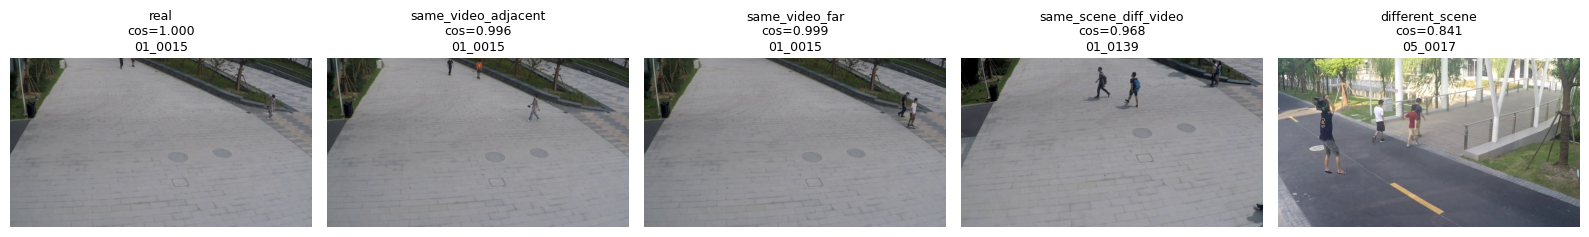

In [27]:
def middle_context_frame_path(record: dict[str, Any]) -> Path:
    paths = record["context_frame_paths"]
    return Path(paths[len(paths) // 2])


def show_context_candidate_grid(query_row: pd.Series) -> None:
    selected = hard_negative_df[hard_negative_df["query_sample_id"] == query_row["query_sample_id"]]
    if selected.empty:
        print("no candidates")
        return
    fig, axes = plt.subplots(1, len(selected), figsize=(3.2 * len(selected), 3.2))
    if len(selected) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, selected.iterrows(), strict=False):
        candidate_idx = int(meta[meta["sample_id"] == row["candidate_sample_id"]]["row_idx"].iloc[0])
        image_path = middle_context_frame_path(records[candidate_idx])
        image = plt.imread(image_path)
        ax.imshow(image)
        ax.axis("off")
        title = chr(10).join(
            [
                str(row["candidate_type"]),
                f"cos={row['context_cos']:.3f}",
                str(row["candidate_video_id"]),
            ]
        )
        ax.set_title(title, fontsize=9)
    plt.tight_layout()
    plt.show()

if not hard_negative_df.empty:
    example_query = hard_negative_df.iloc[0]
    show_context_candidate_grid(example_query)

## 10. 자동 해석 체크

`flag=True`는 추가 확인이 필요한 항목입니다.

In [28]:
checks = []

if "context_transition_summary" in diagnostic_report:
    transition_summary = pd.DataFrame(diagnostic_report["context_transition_summary"])
    for state_name, threshold in [("transition_context", 0.995), ("anomaly_context", 0.990)]:
        state_rows = transition_summary[transition_summary["context_state"] == state_name]
        if not state_rows.empty:
            value = float(state_rows["cos_to_normal_centroid_mean"].iloc[0])
            checks.append(
                {
                    "check": f"{state_name} remains close to same-video normal E_c",
                    "value": value,
                    "flag": bool(np.isfinite(value) and value > threshold),
                    "interpretation": "True면 정상에서 이상으로 넘어가도 E_c가 충분히 달라지지 않음",
                }
            )

if not pair_summary.empty:
    lookup = pair_summary.set_index("category")
    adjacent = float(lookup.loc["same_video_adjacent", "context_cos_mean"]) if "same_video_adjacent" in lookup.index else np.nan
    diff_scene = float(lookup.loc["different_scene", "context_cos_mean"]) if "different_scene" in lookup.index else np.nan
    same_far = float(lookup.loc["same_video_far", "context_cos_mean"]) if "same_video_far" in lookup.index else np.nan
    checks.append(
        {
            "check": "different_scene E_c cosine too high",
            "value": diff_scene,
            "flag": bool(np.isfinite(diff_scene) and diff_scene > 0.90),
            "interpretation": "다른 scene끼리도 E_c가 너무 비슷하면 context feature 구분력이 약할 수 있음",
        }
    )
    checks.append(
        {
            "check": "adjacent vs different_scene margin too small",
            "value": adjacent - diff_scene if np.isfinite(adjacent) and np.isfinite(diff_scene) else np.nan,
            "flag": bool(np.isfinite(adjacent) and np.isfinite(diff_scene) and adjacent - diff_scene < 0.05),
            "interpretation": "인접 window와 다른 scene의 cosine 차이가 작으면 hard shuffle 효과가 약함",
        }
    )
    checks.append(
        {
            "check": "same_video_far close to adjacent",
            "value": adjacent - same_far if np.isfinite(adjacent) and np.isfinite(same_far) else np.nan,
            "flag": bool(np.isfinite(adjacent) and np.isfinite(same_far) and adjacent - same_far < 0.02),
            "interpretation": "같은 video 내 먼 window도 인접 window와 거의 같으면 window-level 변화가 약함",
        }
    )

checks.append(
    {
        "check": "mean temporal cosine too high",
        "value": float(window_stats["temporal_cos_mean"].mean()),
        "flag": bool(float(window_stats["temporal_cos_mean"].mean()) > 0.98),
        "interpretation": "프레임 간 E_c가 거의 변하지 않으면 미래 조건으로 약할 수 있음",
    }
)

if isinstance(probe_summary, dict) and "standardized_r2_vs_mean" in probe_summary:
    checks.append(
        {
            "check": "E_c -> E_v ridge probe weak",
            "value": float(probe_summary["standardized_r2_vs_mean"]),
            "flag": bool(float(probe_summary["standardized_r2_vs_mean"]) < 0.05),
            "interpretation": "pooled E_c가 summarized E_v를 mean baseline보다 거의 잘 예측하지 못함",
        }
    )

if not nn_summary.empty:
    top1_lift = float(nn_summary.loc[nn_summary["k"] == 1, "future_lift_over_random"].iloc[0])
    checks.append(
        {
            "check": "E_c nearest neighbor future lift weak",
            "value": top1_lift,
            "flag": bool(top1_lift < 0.02),
            "interpretation": "E_c로 가까운 window가 random보다 비슷한 E_v를 갖지 않음",
        }
    )

checks_df = pd.DataFrame(checks)
display(checks_df)
diagnostic_report["heuristic_checks"] = checks_df.to_dict("records")

,check,value,flag,interpretation
0,transition_context remains close to same-video...,0.992549,False,True면 정상에서 이상으로 넘어가도 E_c가 충분히 달라지지 않음
1,anomaly_context remains close to same-video no...,0.988995,False,True면 정상에서 이상으로 넘어가도 E_c가 충분히 달라지지 않음
2,different_scene E_c cosine too high,0.872446,False,다른 scene끼리도 E_c가 너무 비슷하면 context feature 구분력이 ...
3,adjacent vs different_scene margin too small,0.122280,False,인접 window와 다른 scene의 cosine 차이가 작으면 hard shuff...
4,same_video_far close to adjacent,0.005630,True,같은 video 내 먼 window도 인접 window와 거의 같으면 window-...
5,mean temporal cosine too high,0.998990,True,프레임 간 E_c가 거의 변하지 않으면 미래 조건으로 약할 수 있음
6,E_c -> E_v ridge probe weak,0.685090,False,pooled E_c가 summarized E_v를 mean baseline보다 거의...
7,E_c nearest neighbor future lift weak,0.385902,False,E_c로 가까운 window가 random보다 비슷한 E_v를 갖지 않음


## 11. 저장

기본 설정에서는 요약 JSON, pair table, hard negative table을 저장합니다. 이 파일은 production artifact가 아니라 분석용입니다.

In [29]:
if SAVE_REPORT:
    REPORT_DIR.mkdir(parents=True, exist_ok=True)
    report_path = REPORT_DIR / f"{FEATURE_SPLIT}_context_diagnostics_report.json"
    pair_path = REPORT_DIR / f"{FEATURE_SPLIT}_context_pair_table.csv"
    hard_negative_path = REPORT_DIR / f"{FEATURE_SPLIT}_hard_context_negatives.csv"
    stats_path = REPORT_DIR / f"{FEATURE_SPLIT}_window_context_stats.csv"
    transition_path = REPORT_DIR / f"{FEATURE_SPLIT}_context_transition_table.csv"

    write_json(report_path, json.loads(json.dumps(diagnostic_report, default=str)))
    pair_df.to_csv(pair_path, index=False)
    hard_negative_df.to_csv(hard_negative_path, index=False)
    window_stats.to_csv(stats_path, index=False)
    if "context_label_df" in globals():
        context_label_df.to_csv(transition_path, index=False)

    print(f"wrote {report_path}")
    print(f"wrote {pair_path}")
    print(f"wrote {hard_negative_path}")
    print(f"wrote {stats_path}")
    if "context_label_df" in globals():
        print(f"wrote {transition_path}")

wrote /workspace/VAD/data/03_features/shanghaitech/context_diagnostics/test_context_diagnostics_report.json
wrote /workspace/VAD/data/03_features/shanghaitech/context_diagnostics/test_context_pair_table.csv
wrote /workspace/VAD/data/03_features/shanghaitech/context_diagnostics/test_hard_context_negatives.csv
wrote /workspace/VAD/data/03_features/shanghaitech/context_diagnostics/test_window_context_stats.csv
wrote /workspace/VAD/data/03_features/shanghaitech/context_diagnostics/test_context_transition_table.csv
